In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

In [2]:
def skew(v):
    """Returns the skew-symmetric matrix S(v)."""
    return np.array([
        [0, -v[2], v[1]],
        [v[2], 0, -v[0]],
        [-v[1], v[0], 0]
    ])

def q_mult(q1, q2):
    """Quaternion multiplication Q1 x Q2."""
    eta1, eps1 = q1[0], q1[1:4]
    eta2, eps2 = q2[0], q2[1:4]
    eta = eta1 * eta2 - np.dot(eps1, eps2)
    eps = eta1 * eps2 + eta2 * eps1 + np.cross(eps1, eps2)
    return np.concatenate(([eta], eps))

def q_inv(q):
    """Quaternion inverse."""
    return np.concatenate(([q[0]], -q[1:4]))

def q_rot(q, v):
    """Rotate vector v by quaternion Q: Q x (0,v) x Q^-1."""
    eta, eps = q[0], q[1:4]
    R = (eta**2 - np.dot(eps, eps)) * np.eye(3) + 2 * np.outer(eps, eps) + 2 * eta * skew(eps)
    return R @ v

def q_to_R(q):
    """Convert quaternion to Rotation matrix."""
    eta, eps = q[0], q[1:4]
    return (eta**2 - np.dot(eps, eps)) * np.eye(3) + 2 * np.outer(eps, eps) + 2 * eta * skew(eps)


g = 9.81
m_act = 1.0  # Actual mass 
theta_true = np.array([0.075, 0.075, 0.015])
J = np.diag([0.075, 0.075, 0.015])  # Actual inertia 
J_inv = np.linalg.inv(J)
z_i = np.array([0.0, 0.0, 1.0])

# Position Gains 
kp = 1.25
kv = 1.0
alpha_p = 1.0
gamma_p = 0.03

# Attitude Gains 
k_eps = 6.5
k_omega = 3.5
alpha_o = 2.0
gamma_o = 0.001
a1 = 0.16
a2 = 1/4.615  # true parameters from Wang23
control_aloc = np.array([[1, 1, 1, 1], [-a1, a1, a1, -a1], [a1, -a1, a1, -a1], [a2, a2, -a2, -a2]])


def get_references(t):
    # Position
    pd = np.array([3 * np.cos(np.pi/20 * t), 
                   3 * np.sin(np.pi/20 * t), 
                   0.5 * np.cos(np.pi/5 * t) + 2])
    
    # Velocity
    vd = np.array([-3 * (np.pi/20) * np.sin(np.pi/20 * t), 
                    3 * (np.pi/20) * np.cos(np.pi/20 * t), 
                   -0.5 * (np.pi/5) * np.sin(np.pi/5 * t)])
    
    # Acceleration
    vd_dot = np.array([-3 * (np.pi/20)**2 * np.cos(np.pi/20 * t), 
                       -3 * (np.pi/20)**2 * np.sin(np.pi/20 * t), 
                       -0.5 * (np.pi/5)**2 * np.cos(np.pi/5 * t)])
    
    psi_d = (np.pi/4)*np.sin(np.pi/10 * t)
    psi_d_dot = (np.pi/4)*(np.pi/10) * np.cos(np.pi/10 * t)
    
    return pd, vd, vd_dot, psi_d, psi_d_dot

## Implementing the Adaptive Controller in the paper (with known control allocation matrix) and plotting the motot forces and other quntities

<>:200: SyntaxWarning: invalid escape sequence '\h'
<>:202: SyntaxWarning: invalid escape sequence '\h'
<>:203: SyntaxWarning: invalid escape sequence '\h'
<>:204: SyntaxWarning: invalid escape sequence '\h'
<>:258: SyntaxWarning: invalid escape sequence '\p'
<>:259: SyntaxWarning: invalid escape sequence '\p'
<>:200: SyntaxWarning: invalid escape sequence '\h'
<>:202: SyntaxWarning: invalid escape sequence '\h'
<>:203: SyntaxWarning: invalid escape sequence '\h'
<>:204: SyntaxWarning: invalid escape sequence '\h'
<>:258: SyntaxWarning: invalid escape sequence '\p'
<>:259: SyntaxWarning: invalid escape sequence '\p'
C:\Users\bhuvn\AppData\Local\Temp\ipykernel_37720\3930780501.py:200: SyntaxWarning: invalid escape sequence '\h'
  ax2.plot(t, m_hat_hist, 'b-', label='$\hat{m}$ (Estimated Mass)')
C:\Users\bhuvn\AppData\Local\Temp\ipykernel_37720\3930780501.py:202: SyntaxWarning: invalid escape sequence '\h'
  ax2.plot(t, theta_hat_hist[0, :], 'g-', label='$\hat{\\theta}_1$ (Est. Inertia X

Simulating closed-loop dynamics...
Simulation complete!


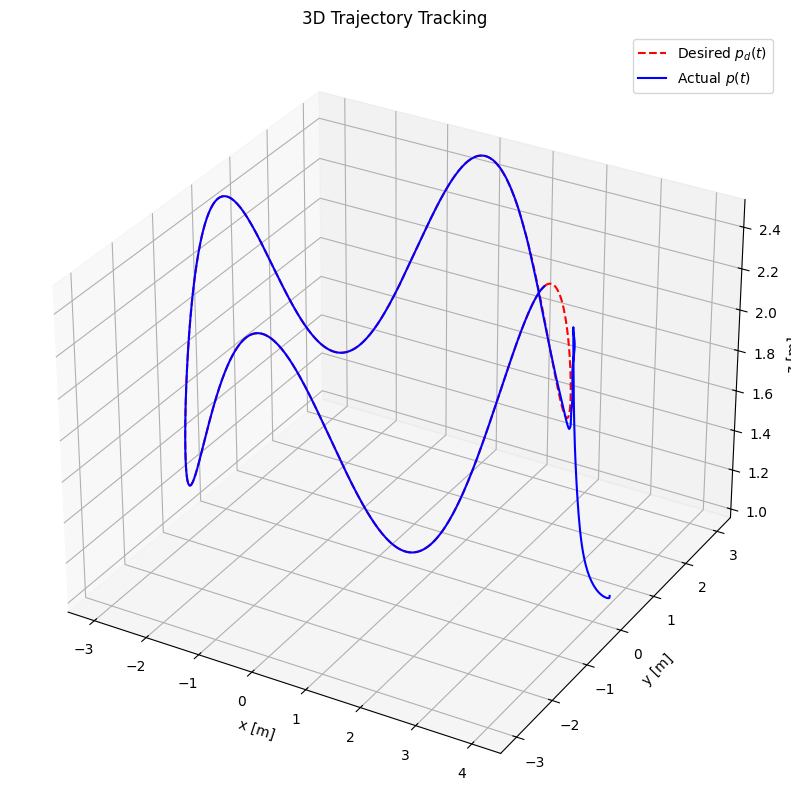

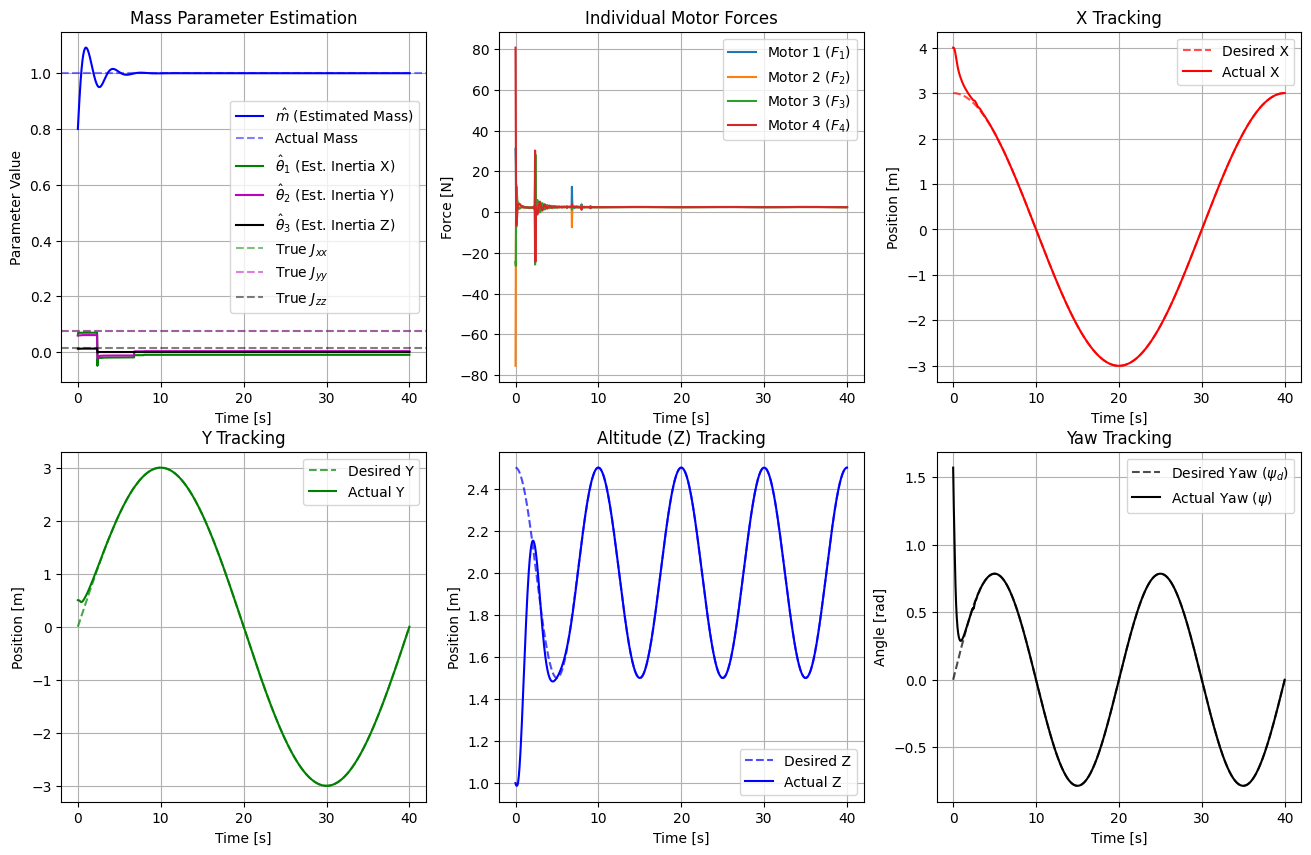

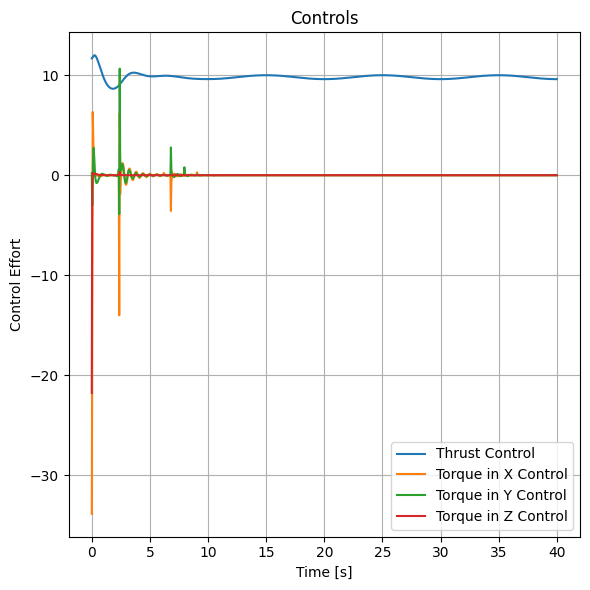

In [ ]:
# memories to calculate the gradients of f and omega_r using finite difference
# the paper imploys a similar technique but using filters

memory_f = {
    't_prev': 0.0,
    'f_prev': np.zeros(3),
    'f_dot_current': np.zeros(3)
}

memory_omega_r = {
    't_prev': 0.0,
    'omega_r_prev': np.zeros(3),
    'omega_r_dot_current': np.zeros(3)
}


def compute_control(t, state):
    # Unpack state
    p = state[0:3]
    v = state[3:6]
    Q = state[6:10]
    # Q = Q / np.linalg.norm(Q)  # Normalize
    omega = state[10:13]
    m_hat = state[13]
    theta_hat = state[14:17]

    pd, vd, vd_dot, psi_d, psi_d_dot = get_references(t)

    # --- Position Controller ---
    p_tilda = pd - p
    v_tilda = vd - v
    vr = vd + kp * p_tilda
    vr_dot = vd_dot + kp * v_tilda
    z = v_tilda + kp * p_tilda
    
    psi_p = vr_dot + g * z_i
    f = kv * z + alpha_p * p_tilda + m_hat * psi_p

    dt = t - memory_f['t_prev']

    if dt > 1e-6:
        f_dot = (f - memory_f['f_prev']) / dt
        memory_f['t_prev'] = t
        memory_f['f_prev'] = f
        memory_f['f_dot_current'] = f_dot
    else:
        f_dot = memory_f['f_dot_current']

    
    m_hat_dot = gamma_p * np.dot(psi_p, z)

    # --- Thrust and Desired Attitude ---
    T_thrust = np.linalg.norm(f)
    r = f / T_thrust if T_thrust > 1e-6 else z_i
    r_z = r[2]
    
    # Compute Qa 
    if r_z > 0.99999: # Hovering singularity protection
        Qa = np.array([1.0, 0.0, 0.0, 0.0])
    else:
        a = (1.0 / np.sqrt(1 - r_z**2)) * np.array([-r[1], r[0], 0])
        Qa = np.concatenate(([np.sqrt((1 + r_z)/2)], np.sqrt((1 - r_z)/2) * a))
    
    
    # Compute r_dot and omega_a 
    r_dot = (1.0 / T_thrust) * (np.eye(3) - np.outer(r, r)) @ f_dot
    omega_a = (1.0 / (1 + r_z)) * np.array([
        -r_dot[1]*(1 + r_z) + r[1]*r_dot[2],
         r_dot[0]*(1 + r_z) - r[0]*r_dot[2],
         r[1]*r_dot[0] - r[0]*r_dot[1]
    ])
    
    # Compute Q_psi and Q_d 
    Q_psi = np.array([np.cos(psi_d/2), 0, 0, np.sin(psi_d/2)])
    Qd = q_mult(Qa, Q_psi)
    
    omega_psi = np.array([0.0, 0.0, psi_d_dot])
    omega_d = omega_psi + q_rot(q_inv(Q_psi), omega_a)

    # --- Attitude Controller ---
    Q_tilda = q_mult(q_inv(Q), Qd) 
    eta_tilda, eps_tilda = Q_tilda[0], Q_tilda[1:4]
    
    eps_bar = np.array([eps_tilda[1], -eps_tilda[0], eta_tilda])
    
    omega_r = q_rot(Q_tilda, omega_d) + k_eps * eps_tilda + 2 * (1/alpha_o) * T_thrust * skew(eps_bar) @ q_rot(q_inv(Q), z)
    z1 = omega_r - omega
    
    if dt > 1e-6:
        omega_r_dot = (omega_r - memory_omega_r['omega_r_prev']) / dt
        memory_omega_r['t_prev'] = t
        memory_omega_r['omega_r_prev'] = omega_r
        memory_omega_r['omega_r_dot_current'] = omega_r_dot
    else:
        omega_r_dot = memory_omega_r['omega_r_dot_current']
    
    # Regressor Matrix Psi_0 
    # J * omega_r_dot + S(omega_r) * J * omega
    Psi_0 = np.array([
        [omega_r_dot[0], -omega_r[2]*omega[1],  omega_r[1]*omega[2]],
        [omega_r[2]*omega[0], omega_r_dot[1],  -omega_r[0]*omega[2]],
        [-omega_r[1]*omega[0], omega_r[0]*omega[1], omega_r_dot[2]]
    ])
    
    tau = k_omega * z1 + alpha_o * eps_tilda + Psi_0 @ theta_hat 
    theta_hat_dot = gamma_o * Psi_0.T @ z1


    return tau, T_thrust, m_hat_dot, theta_hat_dot


def quadrotor_dynamics(t, state):
    p, v, Q, omega = state[0:3], state[3:6], state[6:10], state[10:13]
    Q = Q / np.linalg.norm(Q)

    # Get control effort and actual torques
    tau, T_thrust, m_hat_dot, theta_hat_dot = compute_control(t, state)

    # Physical Plant Dynamics
    p_dot = v
    v_dot = (1.0 / m_act) * (T_thrust * q_to_R(Q) @ z_i - m_act * g * z_i)
    Q_dot = 0.5 * q_mult(Q, np.concatenate(([0.0], omega)))
    omega_dot = J_inv @ (tau - skew(omega) @ J @ omega)

    return np.concatenate((p_dot, v_dot, Q_dot, omega_dot, [m_hat_dot], theta_hat_dot))


t_span = (0, 40)
t_eval = np.linspace(0, 40, 1000)

# Initial Conditions 
initial_state = np.zeros(17)
initial_state[0:3] = [4.0, 0.5, 1.0]           # p(0)
initial_state[3:6] = [0.0, 0.0, -0.2]          # v(0)
initial_state[6:10] = [np.sqrt(2)/2, 0, 0, np.sqrt(2)/2] # Q(0)
initial_state[10:13] = [0.5, 0.0, 0.5]         # omega(0)
initial_state[13] = 0.8 * m_act                       # m_hat(0)
initial_state[14:17] = 0.8 * theta_true         # theta_hat(0)

print("Simulating closed-loop dynamics...")
sol = solve_ivp(quadrotor_dynamics, t_span, initial_state, t_eval=t_eval, method='RK45')
print("Simulation complete!")


# Extract Results
t = sol.t
y = sol.y
p_hist = y[0:3, :]
m_hat_hist = y[13, :]
theta_hat_hist = y[14:17, :]
motor_forces_hist = np.zeros((4, len(t)))
control_effort_f = np.zeros(len(t))
control_effort_tau = np.zeros((3, len(t)))

# Calculate desired trajectory for plotting
pd_hist = np.array([get_references(ti)[0] for ti in t]).T
psi_d_hist = np.array([get_references(ti)[3] for ti in t])

q0, q1, q2, q3 = y[6, :], y[7, :], y[8, :], y[9, :]
psi_hist = np.arctan2(2 * (q0 * q3 + q1 * q2), 1 - 2 * (q2**2 + q3**2))

# resetting the memory to compute the forces and control efforts

memory_f = {
    't_prev': 0.0,
    'f_prev': np.zeros(3),
    'f_dot_current': np.zeros(3)
}

memory_omega_r = {
    't_prev': 0.0,
    'omega_r_prev': np.zeros(3),
    'omega_r_dot_current': np.zeros(3)
}

for i in range(len(t)):
    ti = t[i]
    state_i = y[:, i]
    
    tau_i, T_thrust_i, _, _ = compute_control(ti, state_i)
    
    # Calculate and store the individual motor forces
    motor_forces_hist[:, i] = np.linalg.inv(control_aloc) @ np.array([T_thrust_i, *tau_i])
    control_effort_f[i] = T_thrust_i
    control_effort_tau[:, i] = tau_i


# Plot 1: 3D Trajectory
fig1 = plt.figure(figsize=(10, 10))
ax1 = fig1.add_subplot(111, projection='3d')
ax1.plot(pd_hist[0], pd_hist[1], pd_hist[2], 'r--', label='Desired $p_d(t)$')
ax1.plot(p_hist[0], p_hist[1], p_hist[2], 'b-', label='Actual $p(t)$')
ax1.set_xlabel('x [m]')
ax1.set_ylabel('y [m]')
ax1.set_zlabel('z [m]')
ax1.set_title('3D Trajectory Tracking')
ax1.legend()

fig2 = plt.figure(figsize=(16, 10))
# Plot 2: Parameter Adaptation
ax2 = fig2.add_subplot(231)
ax2.plot(t, m_hat_hist, 'b-', label='$\hat{m}$ (Estimated Mass)')
ax2.axhline(m_act, color='b', linestyle='--', alpha=0.5, label='Actual Mass')
ax2.plot(t, theta_hat_hist[0, :], 'g-', label='$\hat{\\theta}_1$ (Est. Inertia X)')
ax2.plot(t, theta_hat_hist[1, :], 'm-', label='$\hat{\\theta}_2$ (Est. Inertia Y)')
ax2.plot(t, theta_hat_hist[2, :], 'k-', label='$\hat{\\theta}_3$ (Est. Inertia Z)')

ax2.axhline(0.075, color='g', linestyle='--', alpha=0.5, label='True $J_{xx}$')
ax2.axhline(0.075, color='m', linestyle='--', alpha=0.5, label='True $J_{yy}$')
ax2.axhline(0.015, color='k', linestyle='--', alpha=0.5, label='True $J_{zz}$')
ax2.set_xlabel('Time [s]')
ax2.set_ylabel('Parameter Value')
ax2.set_title('Mass Parameter Estimation')
ax2.legend()
ax2.grid(True)

# 3. Motor Forces
ax3 = fig2.add_subplot(232)
ax3.plot(t, motor_forces_hist[0, :], label='Motor 1 ($F_1$)')
ax3.plot(t, motor_forces_hist[1, :], label='Motor 2 ($F_2$)')
ax3.plot(t, motor_forces_hist[2, :], label='Motor 3 ($F_3$)')
ax3.plot(t, motor_forces_hist[3, :], label='Motor 4 ($F_4$)')
ax3.set_xlabel('Time [s]')
ax3.set_ylabel('Force [N]')
ax3.set_title('Individual Motor Forces')
ax3.legend()
ax3.grid(True)

# Plot 4: X and Y Position
ax4 = fig2.add_subplot(233)
ax4.plot(t, pd_hist[0], 'r--', alpha=0.7, label='Desired X')
ax4.plot(t, p_hist[0], 'r-', label='Actual X')
ax4.set_xlabel('Time [s]')
ax4.set_ylabel('Position [m]')
ax4.set_title('X Tracking')
ax4.legend()
ax4.grid(True)

ax4 = fig2.add_subplot(234)
ax4.plot(t, pd_hist[1], 'g--', alpha=0.7, label='Desired Y')
ax4.plot(t, p_hist[1], 'g-', label='Actual Y')
ax4.set_xlabel('Time [s]')
ax4.set_ylabel('Position [m]')
ax4.set_title('Y Tracking')
ax4.legend()
ax4.grid(True)

# Plot 5: Z Position (Altitude)
ax5 = fig2.add_subplot(235)
ax5.plot(t, pd_hist[2], 'b--', alpha=0.7, label='Desired Z')
ax5.plot(t, p_hist[2], 'b-', label='Actual Z')
ax5.set_xlabel('Time [s]')
ax5.set_ylabel('Position [m]')
ax5.set_title('Altitude (Z) Tracking')
ax5.legend()
ax5.grid(True)

# Plot 6: Yaw Angle (Psi)
ax6 = fig2.add_subplot(236)
ax6.plot(t, psi_d_hist, 'k--', alpha=0.7, label='Desired Yaw ($\psi_d$)')
ax6.plot(t, psi_hist, 'k-', label='Actual Yaw ($\psi$)')
ax6.set_xlabel('Time [s]')
ax6.set_ylabel('Angle [rad]')
ax6.set_title('Yaw Tracking')
ax6.legend()
ax6.grid(True)

fig3 = plt.figure(figsize=(6, 6))
ax7 = fig3.add_subplot(111)
ax7.plot(t, control_effort_f, label='Thrust Control')
ax7.plot(t, control_effort_tau[0, :], label='Torque in X Control')
ax7.plot(t, control_effort_tau[1, :], label='Torque in Y Control')
ax7.plot(t, control_effort_tau[2, :], label='Torque in Z Control')
ax7.set_xlabel('Time [s]')
ax7.set_ylabel('Control Effort')
ax7.set_title('Controls')
ax7.legend()
ax7.grid(True)

plt.tight_layout()
plt.show()

## Adaptive Controller with unknown control allocation matrix (analysis in the submitted handwritten pdf)

<>:216: SyntaxWarning: invalid escape sequence '\h'
<>:218: SyntaxWarning: invalid escape sequence '\h'
<>:219: SyntaxWarning: invalid escape sequence '\h'
<>:220: SyntaxWarning: invalid escape sequence '\h'
<>:233: SyntaxWarning: invalid escape sequence '\h'
<>:234: SyntaxWarning: invalid escape sequence '\h'
<>:235: SyntaxWarning: invalid escape sequence '\h'
<>:240: SyntaxWarning: invalid escape sequence '\h'
<>:274: SyntaxWarning: invalid escape sequence '\p'
<>:275: SyntaxWarning: invalid escape sequence '\p'
<>:216: SyntaxWarning: invalid escape sequence '\h'
<>:218: SyntaxWarning: invalid escape sequence '\h'
<>:219: SyntaxWarning: invalid escape sequence '\h'
<>:220: SyntaxWarning: invalid escape sequence '\h'
<>:233: SyntaxWarning: invalid escape sequence '\h'
<>:234: SyntaxWarning: invalid escape sequence '\h'
<>:235: SyntaxWarning: invalid escape sequence '\h'
<>:240: SyntaxWarning: invalid escape sequence '\h'
<>:274: SyntaxWarning: invalid escape sequence '\p'
<>:275: Synt

Simulating closed-loop dynamics with adaptive control allocation...
Simulation complete!


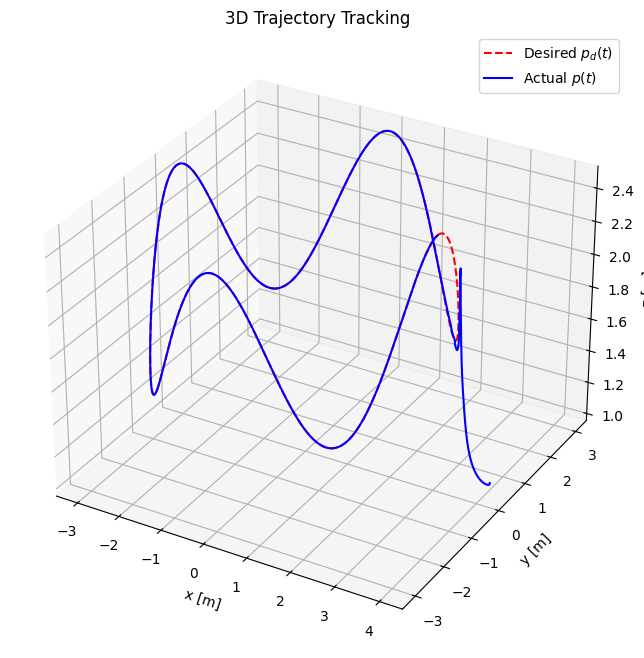

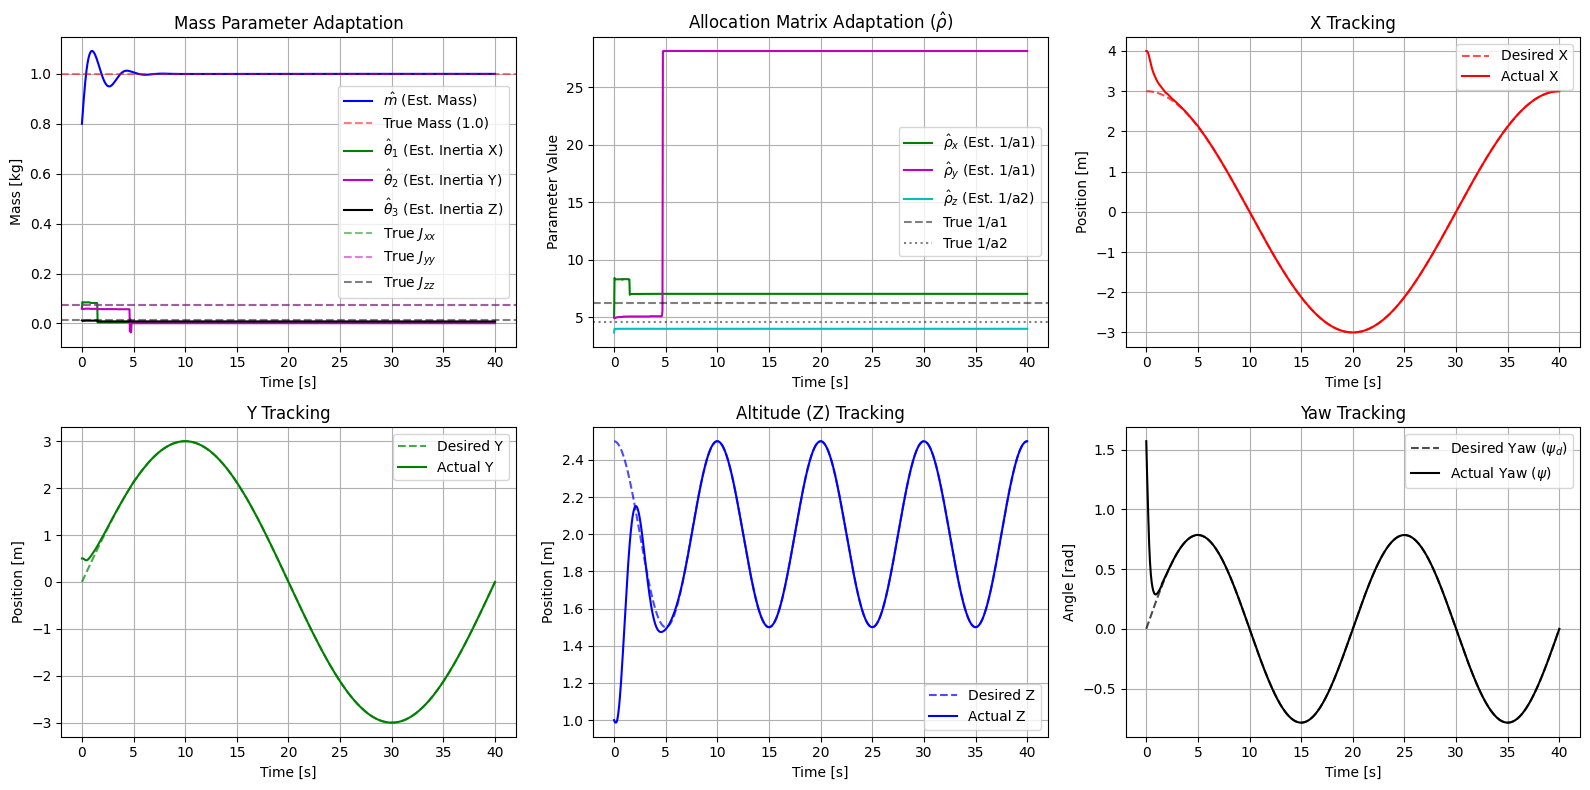

In [10]:

memory_f = {
    't_prev': 0.0,
    'f_prev': np.zeros(3),
    'f_dot_current': np.zeros(3)
}

memory_omega_r = memory = {
    't_prev': 0.0,
    'omega_r_prev': np.zeros(3),
    'omega_r_dot_current': np.zeros(3)
}

# Known Geometric Structure Matrix B
B = np.array([
    [ 1,  1,  1,  1],
    [ -1, 1,  1,  -1],
    [ 1,  -1, 1,  -1],
    [1,  1, -1,  -1]
])
B_inv = np.linalg.inv(B)

# Controller Gains (Pliego20)
kp = 1.25
kv = 1.0
alpha_p = 1.0
gamma_p = 0.03

k_eps = 6.5
k_omega = 3.5
alpha_o = 2.0
gamma_o = 0.001
lambda_0 = np.diag([1, 1/a1, 1/a1, 1/a2 ])



def compute_control_new(t, state):
    """Helper function to extract control effort and actual torques."""
    p, v, Q, omega = state[0:3], state[3:6], state[6:10], state[10:13]
    Q = Q / np.linalg.norm(Q)
    m_hat, theta_hat = state[13], state[14:17]
    rho_hat = state[17:20] 

    pd, vd, vd_dot, psi_d, psi_d_dot = get_references(t)

    # Position Controller
    p_tilda, v_tilda = pd - p, vd - v
    vr_dot = vd_dot + kp * v_tilda
    z = v_tilda + kp * p_tilda
    psi_p = vr_dot + g * z_i
    f = kv * z + alpha_p * p_tilda + m_hat * psi_p 
    
    T_thrust = np.linalg.norm(f)
    r = f / T_thrust if T_thrust > 1e-6 else z_i
    r_z = np.clip(r[2], -1.0, 1.0)
    
    if r_z > 0.99999:
        Qa = np.array([1.0, 0.0, 0.0, 0.0])
    else:
        a = (1.0 / np.sqrt(1 - r_z**2)) * np.array([-r[1], r[0], 0])
        Qa = np.concatenate(([np.sqrt((1 + r_z)/2)], np.sqrt((1 - r_z)/2) * a))

    dt = t - memory_f['t_prev']
    
    if dt > 1e-6:
        f_dot = (f - memory_f['f_prev']) / dt
        memory_f['t_prev'] = t
        memory_f['f_prev'] = f
        memory_f['f_dot_current'] = f_dot
    else:
        f_dot = memory_f['f_dot_current']

    r_dot = (1.0 / T_thrust) * (np.eye(3) - np.outer(r, r)) @ f_dot
    omega_a = (1.0 / (1 + r_z)) * np.array([
        -r_dot[1]*(1 + r_z) + r[1]*r_dot[2],
         r_dot[0]*(1 + r_z) - r[0]*r_dot[2],
         r[1]*r_dot[0] - r[0]*r_dot[1]
    ])
    
    Q_psi = np.array([np.cos(psi_d/2), 0, 0, np.sin(psi_d/2)])
    Qd = q_mult(Qa, Q_psi)
    omega_d = np.array([0.0, 0.0, psi_d_dot]) + q_rot(q_inv(Q_psi), omega_a)

    # Attitude Controller
    Q_tilda = q_mult(q_inv(Q), Qd)
    eps_bar = np.array([Q_tilda[2], -Q_tilda[1], Q_tilda[0]])
    omega_r = q_rot(Q_tilda, omega_d) + k_eps * Q_tilda[1:4] + 2 * (1/alpha_o) * T_thrust * skew(eps_bar) @ q_rot(q_inv(Q), z)
    z1 = omega_r - omega
    
    if dt > 1e-6:
        omega_r_dot = (omega_r - memory_omega_r['omega_r_prev']) / dt
        memory_omega_r['t_prev'] = t
        memory_omega_r['omega_r_prev'] = omega_r
        memory_omega_r['omega_r_dot_current'] = omega_r_dot
    else:
        omega_r_dot = memory_omega_r['omega_r_dot_current']

    Psi_0 = np.array([
        [omega_r_dot[0], -omega_r[2]*omega[1],  omega_r[1]*omega[2]],
        [omega_r[2]*omega[0], omega_r_dot[1],  -omega_r[0]*omega[2]],
        [-omega_r[1]*omega[0], omega_r[0]*omega[1], omega_r_dot[2]]
    ])
    
    # Desired Virtual Torque
    tau_d = k_omega * z1 + alpha_o * Q_tilda[1:4] + Psi_0 @ theta_hat 


    # The Value of control based on estimates of the parameters of the allocation matrrix
    motor_forces = np.linalg.inv(B) @ np.diag([1, *rho_hat]) @ np.array([T_thrust, *tau_d])

    # Adaptation Laws
    m_hat_dot = gamma_p * np.dot(psi_p, z)
    theta_hat_dot = gamma_o * Psi_0.T @ z1
    
    # New adaptation law for rho
    rho_hat_dot = np.diag(tau_d) @ z1

    return motor_forces, m_hat_dot, theta_hat_dot, rho_hat_dot

def quadrotor_dynamics_new(t, state):
    p, v, Q, omega = state[0:3], state[3:6], state[6:10], state[10:13]
    Q = Q / np.linalg.norm(Q)

    # Get control effort and actual torques
    motor_forces, m_hat_dot, theta_hat_dot, rho_hat_dot = compute_control_new(t, state)

    # Physical Plant Dynamics
    controls_we_will_get = control_aloc @ motor_forces
    T_thrust = controls_we_will_get[0] # this is same as what we desired (explaination in the handwritten pdf)
    tau_act = controls_we_will_get[1:4] # this wont be equal to the desired torque because of the unknown parameters a1 and a2

    p_dot = v
    v_dot = (1.0 / m_act) * (T_thrust * q_to_R(Q) @ z_i - m_act * g * z_i)
    Q_dot = 0.5 * q_mult(Q, np.concatenate(([0.0], omega)))
    omega_dot = J_inv @ (tau_act - skew(omega) @ J @ omega)

    return np.concatenate((p_dot, v_dot, Q_dot, omega_dot, [m_hat_dot], theta_hat_dot, rho_hat_dot))


t_span = (0, 40)
t_eval = np.linspace(0, 40, 1000)

initial_state = np.zeros(20)
initial_state[0:3] = [4.0, 0.5, 1.0]          
initial_state[3:6] = [0.0, 0.0, -0.2]         
initial_state[6:10] = [np.sqrt(2)/2, 0, 0, np.sqrt(2)/2] 
initial_state[10:13] = [0.5, 0.0, 0.5]        
initial_state[13] = 0.8 * m_act                      # Initial mass estimate
initial_state[14:17] = 0.8 * theta_true         # Initial inertia estimate

# Initial Allocation parameter estimates
initial_state[17:20] = 0.8 * np.array([1/a1, 1/a1, 1/a2])        

print("Simulating closed-loop dynamics with adaptive control allocation...")
sol = solve_ivp(quadrotor_dynamics_new, t_span, initial_state, t_eval=t_eval, method='RK45')
print("Simulation complete!")

t = sol.t
p_hist = sol.y[0:3, :]
m_hat_hist = sol.y[13, :]
theta_hat_hist = sol.y[14:17, :]
rho_hat_hist = sol.y[17:20, :]
motor_forces_hist = np.zeros((4, len(t)))
control_effort_f = np.zeros(len(t))
control_effort_tau = np.zeros((3, len(t)))

y = sol.y

pd_hist = np.array([get_references(ti)[0] for ti in t]).T
psi_d_hist = np.array([get_references(ti)[3] for ti in t])

q0, q1, q2, q3 = y[6, :], y[7, :], y[8, :], y[9, :]
psi_hist = np.arctan2(2 * (q0 * q3 + q1 * q2), 1 - 2 * (q2**2 + q3**2))

memory_f = {
    't_prev': 0.0,
    'f_prev': np.zeros(3),
    'f_dot_current': np.zeros(3)
}

memory_omega_r = {
    't_prev': 0.0,
    'omega_r_prev': np.zeros(3),
    'omega_r_dot_current': np.zeros(3)
}

for i in range(len(t)):
    ti = t[i]
    state_i = y[:, i]
    
    motor_forces, _, _, _ = compute_control_new(ti, state_i)
    
    # Calculate and store the individual motor forces
    motor_forces_hist[:, i] = motor_forces
    controls = control_aloc @ motor_forces
    control_effort_f[i] = controls[0]
    control_effort_tau[:, i] = controls[1:4]



fig1 = plt.figure(figsize=(8, 8))

# 1. 3D Trajectory
ax1 = fig1.add_subplot(111, projection='3d')
ax1.plot(pd_hist[0], pd_hist[1], pd_hist[2], 'r--', label='Desired $p_d(t)$')
ax1.plot(p_hist[0], p_hist[1], p_hist[2], 'b-', label='Actual $p(t)$')
ax1.set_xlabel('x [m]')
ax1.set_ylabel('y [m]')
ax1.set_zlabel('z [m]')
ax1.set_title('3D Trajectory Tracking')
ax1.legend()

fig2 = plt.figure(figsize=(16, 8))

# 2. Mass Adaptation
ax2 = fig2.add_subplot(231)
ax2.plot(t, m_hat_hist, 'b-', label='$\hat{m}$ (Est. Mass)')
ax2.axhline(m_act, color='r', linestyle='--', alpha=0.5, label='True Mass (1.0)')
ax2.plot(t, theta_hat_hist[0, :], 'g-', label='$\hat{\\theta}_1$ (Est. Inertia X)')
ax2.plot(t, theta_hat_hist[1, :], 'm-', label='$\hat{\\theta}_2$ (Est. Inertia Y)')
ax2.plot(t, theta_hat_hist[2, :], 'k-', label='$\hat{\\theta}_3$ (Est. Inertia Z)')

ax2.axhline(0.075, color='g', linestyle='--', alpha=0.5, label='True $J_{xx}$')
ax2.axhline(0.075, color='m', linestyle='--', alpha=0.5, label='True $J_{yy}$')
ax2.axhline(0.015, color='k', linestyle='--', alpha=0.5, label='True $J_{zz}$')
ax2.set_xlabel('Time [s]')
ax2.set_ylabel('Mass [kg]')
ax2.set_title('Mass Parameter Adaptation')
ax2.legend()
ax2.grid(True)

# 3. Control Allocation Adaptation (Wang23 Integration)
ax3 = fig2.add_subplot(232)
ax3.plot(t, rho_hat_hist[0], 'g-', label='$\hat{\\rho}_x$ (Est. 1/a1)')
ax3.plot(t, rho_hat_hist[1], 'm-', label='$\hat{\\rho}_y$ (Est. 1/a1)')
ax3.plot(t, rho_hat_hist[2], 'c-', label='$\hat{\\rho}_z$ (Est. 1/a2)')
ax3.axhline(1/a1, color='k', linestyle='--', alpha=0.5, label='True 1/a1')
ax3.axhline(1/a2, color='k', linestyle=':', alpha=0.5, label='True 1/a2')
ax3.set_xlabel('Time [s]')
ax3.set_ylabel('Parameter Value')
ax3.set_title('Allocation Matrix Adaptation ($\hat{\\rho}$)')
ax3.legend()
ax3.grid(True)

ax4 = fig2.add_subplot(233)
ax4.plot(t, pd_hist[0], 'r--', alpha=0.7, label='Desired X')
ax4.plot(t, p_hist[0], 'r-', label='Actual X')
ax4.set_xlabel('Time [s]')
ax4.set_ylabel('Position [m]')
ax4.set_title('X Tracking')
ax4.legend()
ax4.grid(True)

ax4 = fig2.add_subplot(234)
ax4.plot(t, pd_hist[1], 'g--', alpha=0.7, label='Desired Y')
ax4.plot(t, p_hist[1], 'g-', label='Actual Y')
ax4.set_xlabel('Time [s]')
ax4.set_ylabel('Position [m]')
ax4.set_title('Y Tracking')
ax4.legend()
ax4.grid(True)

# Plot 5: Z Position (Altitude)
ax5 = fig2.add_subplot(235)
ax5.plot(t, pd_hist[2], 'b--', alpha=0.7, label='Desired Z')
ax5.plot(t, p_hist[2], 'b-', label='Actual Z')
ax5.set_xlabel('Time [s]')
ax5.set_ylabel('Position [m]')
ax5.set_title('Altitude (Z) Tracking')
ax5.legend()
ax5.grid(True)

# Plot 6: Yaw Angle (Psi)
ax6 = fig2.add_subplot(236)
ax6.plot(t, psi_d_hist, 'k--', alpha=0.7, label='Desired Yaw ($\psi_d$)')
ax6.plot(t, psi_hist, 'k-', label='Actual Yaw ($\psi$)')
ax6.set_xlabel('Time [s]')
ax6.set_ylabel('Angle [rad]')
ax6.set_title('Yaw Tracking')
ax6.legend()
ax6.grid(True)


plt.tight_layout()
plt.show()

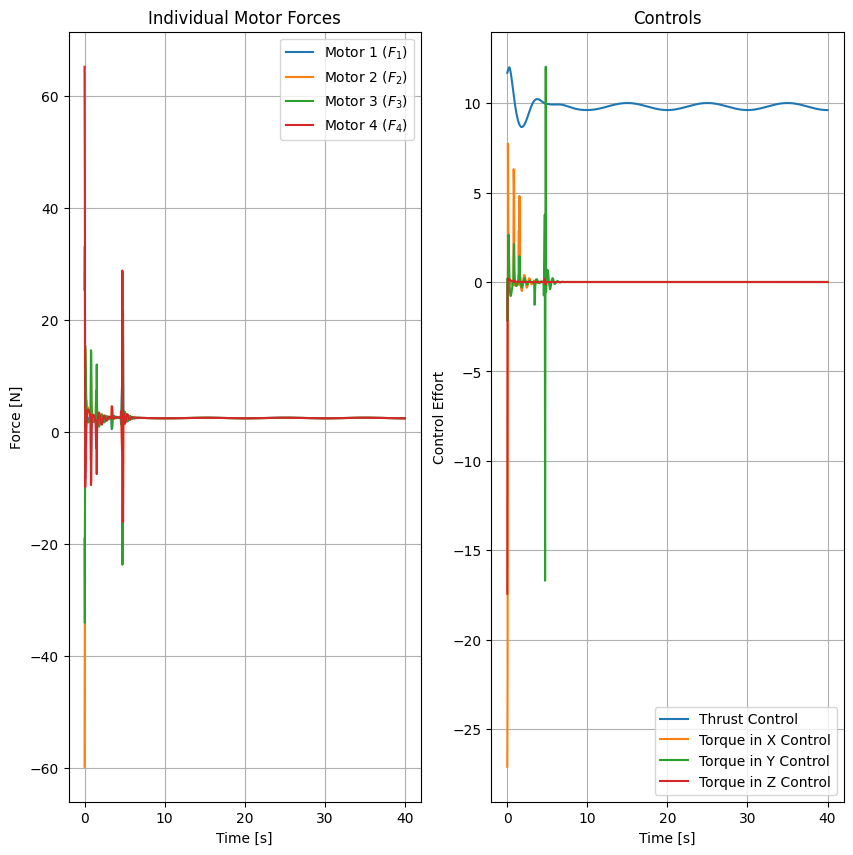

In [11]:
fig3 = plt.figure(figsize=(10, 10))
ax7 = fig3.add_subplot(121)
ax7.plot(t, motor_forces_hist[0, :], label='Motor 1 ($F_1$)')
ax7.plot(t, motor_forces_hist[1, :], label='Motor 2 ($F_2$)')
ax7.plot(t, motor_forces_hist[2, :], label='Motor 3 ($F_3$)')
ax7.plot(t, motor_forces_hist[3, :], label='Motor 4 ($F_4$)')
ax7.set_xlabel('Time [s]')
ax7.set_ylabel('Force [N]')
ax7.set_title('Individual Motor Forces')
ax7.legend()
ax7.grid(True)

ax8 = fig3.add_subplot(122)
ax8.plot(t, control_effort_f, label='Thrust Control')
ax8.plot(t, control_effort_tau[0, :], label='Torque in X Control')
ax8.plot(t, control_effort_tau[1, :], label='Torque in Y Control')
ax8.plot(t, control_effort_tau[2, :], label='Torque in Z Control')
ax8.set_xlabel('Time [s]')
ax8.set_ylabel('Control Effort')
ax8.set_title('Controls')
ax8.legend()
ax8.grid(True)

Note that control effort in the second part isn't the actual control. The actual control are the motor forces (left plot). It has been named control effort just to be consistent with part A above, where the control allocation matrix was know, and the Thrust and Torque were actually the things that we could control directly. 